# AutoKeras API Tutorial

Learn AutoKeras basics for electricity load forecasting.

In [9]:
!python -m pip uninstall -y \
  tensorflow-cpu-aws tensorflow tensorflow-text tensorflow-estimator \
  keras tf_keras keras-core keras-nlp keras-hub keras-tuner \
  tensorboard ml-dtypes
!python -m pip install -U pip


Found existing installation: tensorflow-cpu-aws 2.15.0
Uninstalling tensorflow-cpu-aws-2.15.0:
  Successfully uninstalled tensorflow-cpu-aws-2.15.0
Found existing installation: tensorflow 2.18.1
Uninstalling tensorflow-2.18.1:
  Successfully uninstalled tensorflow-2.18.1
Found existing installation: tensorflow-text 2.18.1
Uninstalling tensorflow-text-2.18.1:
  Successfully uninstalled tensorflow-text-2.18.1
Found existing installation: keras 3.12.0
Uninstalling keras-3.12.0:
  Successfully uninstalled keras-3.12.0
Found existing installation: tf_keras 2.18.0
Uninstalling tf_keras-2.18.0:
  Successfully uninstalled tf_keras-2.18.0
Found existing installation: keras-core 0.1.7
Uninstalling keras-core-0.1.7:
  Successfully uninstalled keras-core-0.1.7
Found existing installation: keras-nlp 0.6.4
Uninstalling keras-nlp-0.6.4:
  Successfully uninstalled keras-nlp-0.6.4
Found existing installation: keras-tuner 1.3.5
Uninstalling keras-tuner-1.3.5:
  Successfully uninstalled keras-tuner-1.3.5

In [10]:
!python -m pip install \
  "tensorflow==2.18.1" \
  "tensorflow-text==2.18.1" \
  "tf_keras==2.18.0" \
  "keras-tuner<1.4" \
  "keras-nlp==0.6.4" \
  "autokeras==1.1.0"


  Using cached tensorflow-2.18.1-cp310-cp310-manylinux_2_17_aarch64.manylinux2014_aarch64.whl.metadata (4.0 kB)
  Using cached tensorflow_text-2.18.1-cp310-cp310-manylinux_2_17_aarch64.manylinux2014_aarch64.whl.metadata (1.8 kB)
  Using cached tf_keras-2.18.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached keras_tuner-1.3.5-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras_nlp-0.6.4-py3-none-any.whl.metadata (8.5 kB)
  Using cached tensorboard-2.18.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached keras-3.12.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached keras_core-0.1.7-py3-none-any.whl.metadata (4.3 kB)
Using cached tensorflow-2.18.1-cp310-cp310-manylinux_2_17_aarch64.manylinux2014_aarch64.whl (231.8 MB)
Using cached tensorflow_text-2.18.1-cp310-cp310-manylinux_2_17_aarch64.manylinux2014_aarch64.whl (5.4 MB)
Using cached tf_keras-2.18.0-py3-none-any.whl (1.7 MB)
Using cached keras_nlp-0.6.4-py3-none-any.whl (584 kB)
Using cached keras_tuner-1.3.5-py3-none-any.whl (176 

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import sys
sys.path.append('../utils')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print('✅ Imports successful')

✅ Imports successful


In [3]:
import tensorflow as tf
import autokeras as ak

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')
print(f'AutoKeras: {ak.__version__}')

Using TensorFlow backend
TensorFlow: 2.18.1
AutoKeras: 1.1.0


In [4]:
from AutoKeras_Electricity_Load_Forecasting_utils import (
    ElectricityDataPreprocessor,
    AutoKerasForecaster,
    BaselineModels,
    ForecastVisualizer,
    print_evaluation_metrics
)

print('✅ Utils imported')

✅ Utils imported


## Simple AutoKeras Example

In [5]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

X, y = make_regression(n_samples=500, n_features=10, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training: {len(X_train)} samples')
print(f'Test: {len(X_test)} samples')

Training: 400 samples
Test: 100 samples


In [6]:
reg = ak.StructuredDataRegressor(max_trials=2, overwrite=True, seed=42)

print('Training AutoKeras...')
reg.fit(X_train, y_train, validation_split=0.2, verbose=0)
print('✅ Training complete')

Training AutoKeras...
INFO:tensorflow:Oracle triggered exit


INFO:tensorflow:Oracle triggered exit


INFO:tensorflow:Assets written to: ./structured_data_regressor/best_model/assets


INFO:tensorflow:Assets written to: ./structured_data_regressor/best_model/assets


✅ Training complete


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

pred = reg.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

4/4 [==============================] - 0s 701us/step
MAE: 2.5749
RMSE: 3.9858


## Time Series Feature Engineering

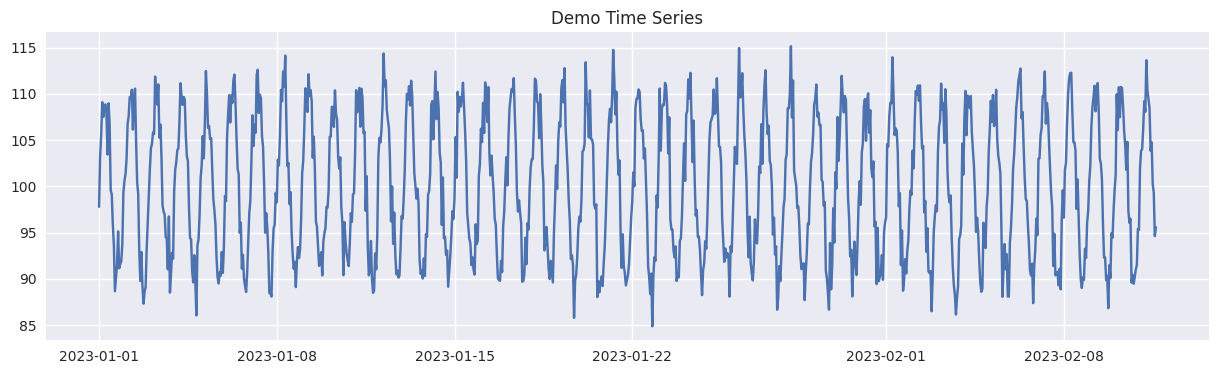

In [8]:
dates = pd.date_range('2023-01-01', periods=1000, freq='h')
values = 100 + 10*np.sin(np.arange(1000)*2*np.pi/24) + np.random.randn(1000)*2
df = pd.DataFrame({'Datetime': dates, 'Load': values})

plt.figure(figsize=(15, 4))
plt.plot(df['Datetime'], df['Load'])
plt.title('Demo Time Series')
plt.show()

In [9]:
df.to_csv('../data/demo_data.csv', index=False)

preprocessor = ElectricityDataPreprocessor()
df = preprocessor.load_and_prepare_data('../data/demo_data.csv', 'Datetime', 'Load')

print(f'Data loaded: {df.shape}')

Data loaded: (1000, 1)


In [10]:
df_features = preprocessor.prepare_features(df, 'Load', create_lags=True, create_rolling=True)

print(f'Original: 1 feature')
print(f'Engineered: {df_features.shape[1]} features')
print(f'Added: {df_features.shape[1]-1} features')

Original: 1 feature
Engineered: 40 features
Added: 39 features


In [11]:
X_train, X_val, X_test, y_train, y_val, y_test = preprocessor.split_data(df_features, 'Load', test_size=0.2, val_size=0.1)
X_train_s, X_val_s, X_test_s = preprocessor.normalize_features(X_train, X_val, X_test)

print(f'Train: {len(X_train)}')
print(f'Val: {len(X_val)}')
print(f'Test: {len(X_test)}')

Train: 598
Val: 67
Test: 167


In [12]:
forecaster = AutoKerasForecaster(max_trials=2, epochs=10, seed=42)
forecaster.build_model(X_train_s, y_train)
forecaster.train(X_train_s, y_train, X_val_s, y_val, verbose=0)
print('✅ Training complete')

AutoKeras model initialized with 2 max trials
Input shape: (598, 39)

Starting AutoKeras Model Training
Training samples: 598
Validation samples: 67
Max trials: 2
Epochs per trial: 10

INFO:tensorflow:Oracle triggered exit


INFO:tensorflow:Oracle triggered exit


INFO:tensorflow:Assets written to: ./structured_data_regressor/best_model/assets


INFO:tensorflow:Assets written to: ./structured_data_regressor/best_model/assets



Training Complete!
✅ Training complete


6/6 [==============================] - 0s 649us/step

AutoKeras Performance Metrics
MAE            : 8.92
RMSE           : 11.38
MAPE           : 8.85%



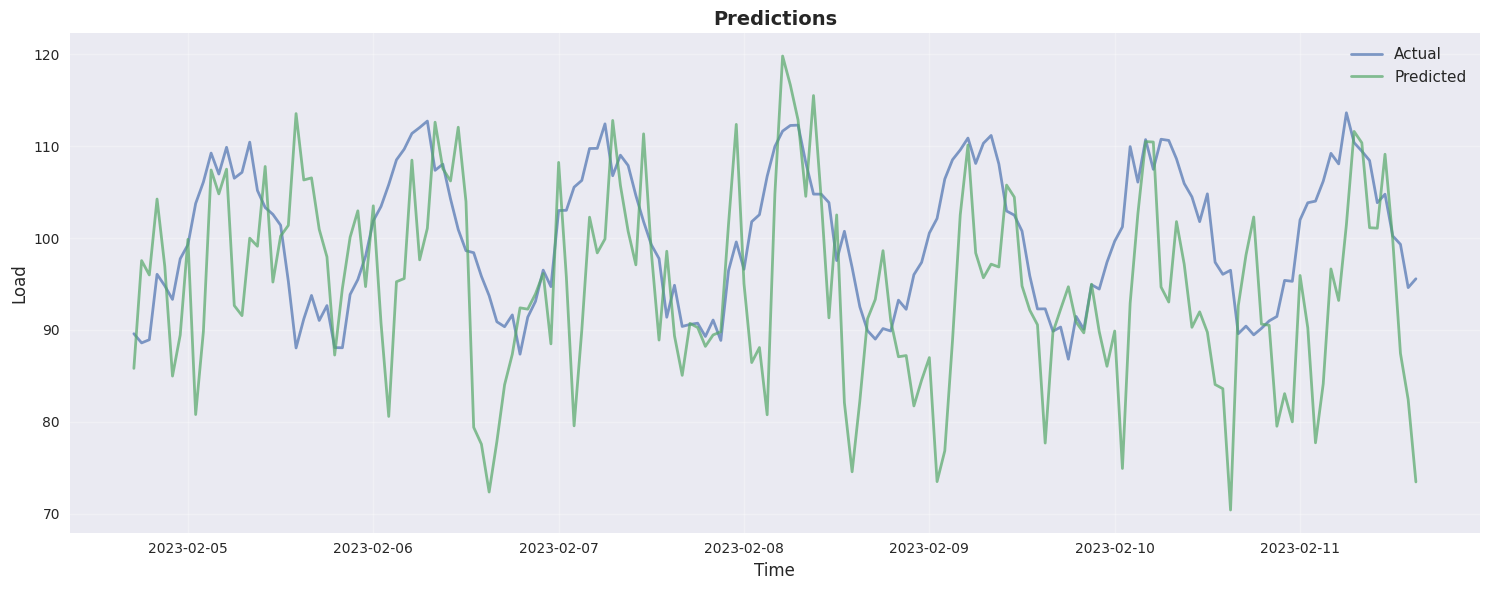

In [13]:
metrics, predictions = forecaster.evaluate(X_test_s, y_test)
print_evaluation_metrics(metrics, 'AutoKeras')

viz = ForecastVisualizer()
viz.plot_predictions(y_test, predictions, 'Predictions')
plt.show()

## Summary

We learned:
- AutoKeras StructuredDataRegressor
- Time series feature engineering
- Our wrapper utilities

